<a href="https://colab.research.google.com/github/vinayak10M/-Assingment_Supervised_Learning_Vinayak.ipynb/blob/main/Casestudy_Supervised_Learning_Vinayak.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np


In [6]:
train_df = pd.read_csv('/content/drive/MyDrive/DSA/Case study on Supervised learning/Training_data.csv')
test_df = pd.read_csv('/content/drive/MyDrive/DSA/Case study on Supervised learning/Testing_data.csv')

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
train_df = pd.DataFrame(train_df)
test_df = pd.DataFrame(test_df)

In [9]:
train_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


In [10]:
train_df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [11]:
train_df.isnull().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [12]:
#Missing values of Gender filled by taking mode

gender_mode = train_df['gender'].mode()[0]
train_df['gender'] = train_df['gender'].fillna(gender_mode)

In [13]:
#Missing values of Online Security filled by taking mode
security_mode = train_df['OnlineSecurity'].mode()[0]
train_df['OnlineSecurity'] = train_df['OnlineSecurity'].fillna(security_mode)

In [14]:
#Missing values of Monthly Charges filled by taking median
monthly_median = train_df['MonthlyCharges'].median()
train_df['MonthlyCharges'] = train_df['MonthlyCharges'].fillna(monthly_median)

In [15]:
#Missing values of Total Charges filled by taking median
train_df['TotalCharges'] = pd.to_numeric(train_df['TotalCharges'], errors='coerce')
total_median = train_df['TotalCharges'].median()
train_df['TotalCharges'] = train_df['TotalCharges'].fillna(total_median)

In [16]:
train_df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [17]:
train_df.duplicated().sum()

np.int64(0)

In [18]:
train_df['customerID'].value_counts()

,count
customerID,
3402-XRIUO,1
9509-MPYOD,1
3082-VQXNH,1
8190-ZTQFB,1
1258-YMZNM,1
...,...
4697-LUPSU,1
7048-GXDAY,1
6682-VCIXC,1


In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: title={'center': 'Histogram of tenure'}, xlabel='tenure', ylabel='Count'>

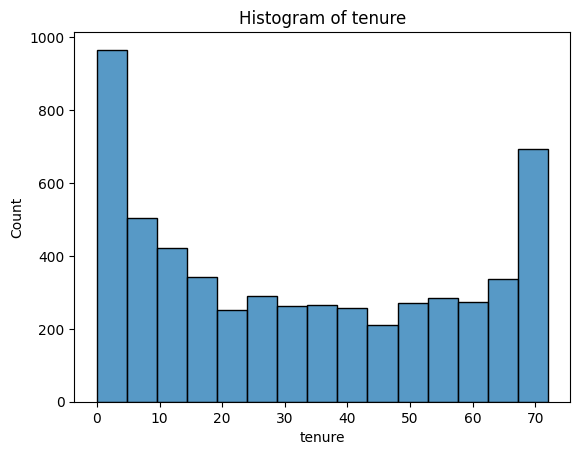

In [20]:
plt.title('Histogram of tenure')
sns.histplot(data=train_df,x='tenure',bins=15)

<Axes: title={'center': 'Boxplot of tenure'}, ylabel='tenure'>

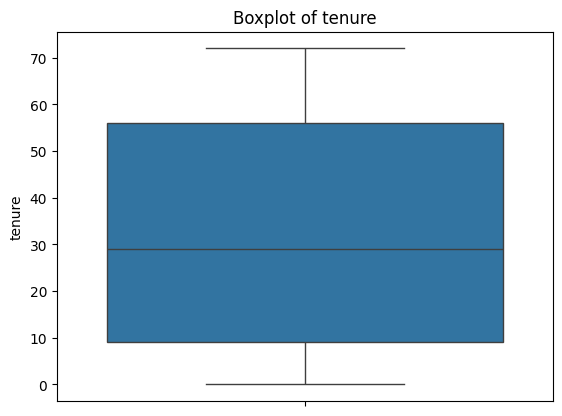

In [21]:
plt.title('Boxplot of tenure')
sns.boxplot(data=train_df,y='tenure')

<Axes: title={'center': 'Histogram of monthly charges'}, xlabel='MonthlyCharges', ylabel='Count'>

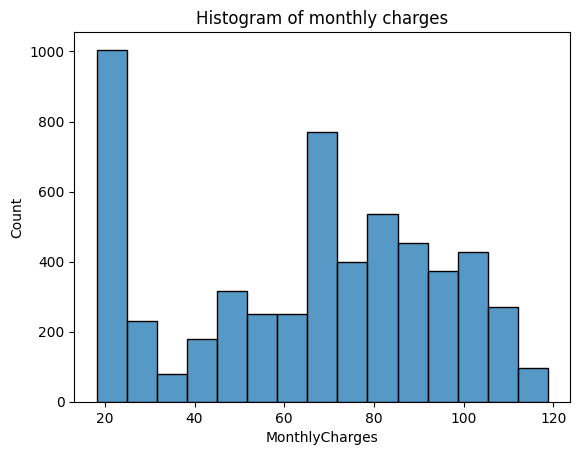

In [22]:
plt.title('Histogram of monthly charges')
sns.histplot(data=train_df,x='MonthlyCharges',bins=15)

<Axes: title={'center': 'Boxplot of monthly charge'}, ylabel='MonthlyCharges'>

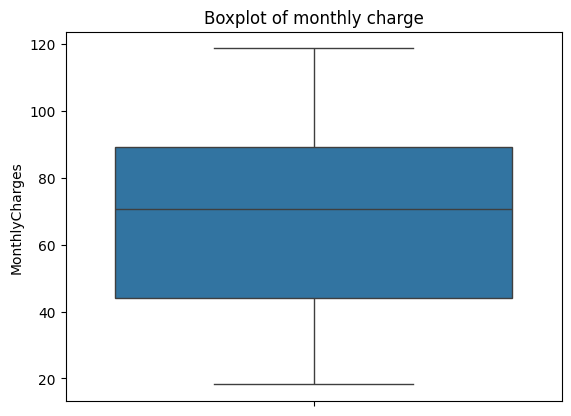

In [23]:
plt.title('Boxplot of monthly charge')
sns.boxplot(data=train_df,y='MonthlyCharges')

<Axes: title={'center': 'Histogram of total charges'}, xlabel='TotalCharges', ylabel='Count'>

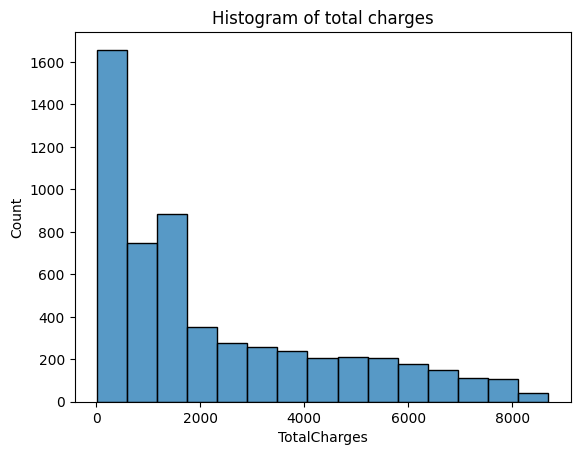

In [24]:
plt.title('Histogram of total charges')
sns.histplot(data=train_df,x='TotalCharges',bins=15)

<Axes: title={'center': 'Boxplot of total charge'}, ylabel='TotalCharges'>

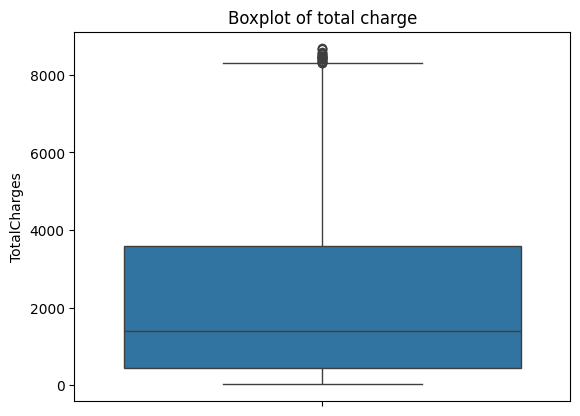

In [25]:
plt.title('Boxplot of total charge')
sns.boxplot(data=train_df,y='TotalCharges')

In [26]:
#IDentify outliers
from numpy._core.defchararray import upper
Q1 = np.percentile(train_df['TotalCharges'],25,interpolation='midpoint')
Q3 = np.percentile(train_df['TotalCharges'],75,interpolation='midpoint')
IQR = Q3-Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
print(Q1,Q3,IQR,lower_bound,upper_bound)


446.07500000000005 3589.825 3143.75 -4269.55 8305.45


In [27]:
for x in train_df['TotalCharges']:
  if((x<lower_bound) or (x>upper_bound)):
    print(x)

8349.45
8496.7
8476.5
8309.55
8317.95
8332.15
8404.9
8425.15
8306.05
8670.1
8684.8
8468.2
8333.95
8594.4
8399.15
8456.75
8436.25
8477.6
8425.3
8543.25
8672.45
8564.75
8349.7
8529.5
8424.9


In [28]:
#Handling Outliers
train_df.TotalCharges = train_df['TotalCharges'].clip(lower_bound,upper_bound)

<Axes: title={'center': 'Boxplot of total charge'}, ylabel='TotalCharges'>

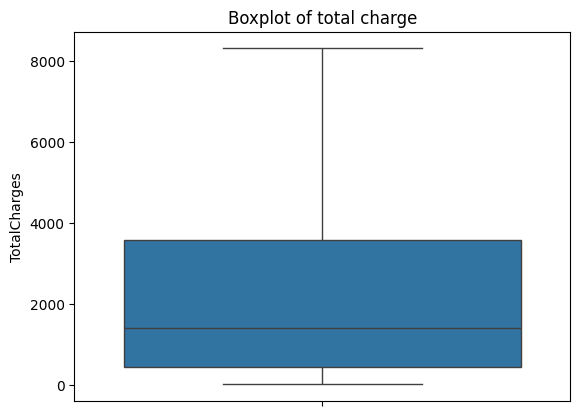

In [29]:
plt.title('Boxplot of total charge')
sns.boxplot(data=train_df,y='TotalCharges')

In [30]:
train_df.drop('customerID',axis=1,inplace=True)

In [31]:
train_df['gender'].value_counts()

,count
gender,
Male,2913
Female,2721


In [32]:
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder

In [33]:
train_df['gender'] = train_df['gender'].map({'Male':0,'Female':1})
train_df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,No,No,35,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,1,0,No,No,28,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.40,No
2,0,0,No,No,56,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,0,0,Yes,No,39,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790.00,No
4,1,0,Yes,Yes,43,No,No phone service,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.60,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,0,0,No,No,51,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.00,5038.15,No
5630,0,1,Yes,No,68,No,No phone service,DSL,Yes,Yes,Yes,No,No,No,Two year,Yes,Electronic check,41.95,2965.75,No
5631,0,0,Yes,Yes,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.95,1322.85,No
5632,1,0,No,No,69,Yes,No,DSL,No,No,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),82.45,5555.30,No


In [34]:
train_df['Partner'].value_counts()

,count
Partner,
No,2890
Yes,2744


In [35]:
label_en = LabelEncoder()
train_df['Partner'] = label_en.fit_transform(train_df['Partner'])
train_df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,0,No,35,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,1,0,0,No,28,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.40,No
2,0,0,0,No,56,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,0,0,1,No,39,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790.00,No
4,1,0,1,Yes,43,No,No phone service,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.60,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,0,0,0,No,51,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.00,5038.15,No
5630,0,1,1,No,68,No,No phone service,DSL,Yes,Yes,Yes,No,No,No,Two year,Yes,Electronic check,41.95,2965.75,No
5631,0,0,1,Yes,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.95,1322.85,No
5632,1,0,0,No,69,Yes,No,DSL,No,No,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),82.45,5555.30,No


In [36]:
train_df['Dependents'].value_counts()

,count
Dependents,
No,3960
Yes,1674


In [37]:
train_df['Dependents'] = label_en.fit_transform(train_df['Dependents'])
train_df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,0,0,35,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,1,0,0,0,28,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.40,No
2,0,0,0,0,56,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,0,0,1,0,39,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790.00,No
4,1,0,1,1,43,No,No phone service,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.60,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,0,0,0,0,51,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.00,5038.15,No
5630,0,1,1,0,68,No,No phone service,DSL,Yes,Yes,Yes,No,No,No,Two year,Yes,Electronic check,41.95,2965.75,No
5631,0,0,1,1,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.95,1322.85,No
5632,1,0,0,0,69,Yes,No,DSL,No,No,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),82.45,5555.30,No


In [38]:
train_df['PhoneService'].value_counts()

,count
PhoneService,
Yes,5081
No,553


In [39]:
train_df['PhoneService'] = label_en.fit_transform(train_df['PhoneService'])
train_df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,0,0,35,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,1,0,0,0,28,0,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.40,No
2,0,0,0,0,56,1,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,0,0,1,0,39,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790.00,No
4,1,0,1,1,43,0,No phone service,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.60,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,0,0,0,0,51,1,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.00,5038.15,No
5630,0,1,1,0,68,0,No phone service,DSL,Yes,Yes,Yes,No,No,No,Two year,Yes,Electronic check,41.95,2965.75,No
5631,0,0,1,1,72,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.95,1322.85,No
5632,1,0,0,0,69,1,No,DSL,No,No,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),82.45,5555.30,No


In [40]:
train_df['MultipleLines'].value_counts()

,count
MultipleLines,
No,2701
Yes,2380
No phone service,553


In [41]:
oe = OrdinalEncoder()

In [42]:
train_df['MultipleLines'] = oe.fit_transform(train_df[['MultipleLines']])
train_df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,0,0,35,1,0.0,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,1,0,0,0,28,0,1.0,DSL,No,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.40,No
2,0,0,0,0,56,1,2.0,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,0,0,1,0,39,1,0.0,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790.00,No
4,1,0,1,1,43,0,1.0,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.60,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,0,0,0,0,51,1,0.0,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.00,5038.15,No
5630,0,1,1,0,68,0,1.0,DSL,Yes,Yes,Yes,No,No,No,Two year,Yes,Electronic check,41.95,2965.75,No
5631,0,0,1,1,72,1,0.0,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.95,1322.85,No
5632,1,0,0,0,69,1,0.0,DSL,No,No,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),82.45,5555.30,No


In [43]:
train_df['OnlineSecurity'] = oe.fit_transform(train_df[['OnlineSecurity']])
train_df['OnlineBackup'] = oe.fit_transform(train_df[['OnlineBackup']])
train_df['DeviceProtection'] = oe.fit_transform(train_df[['DeviceProtection']])
train_df['TechSupport'] = oe.fit_transform(train_df[['TechSupport']])
train_df['StreamingTV'] = oe.fit_transform(train_df[['StreamingTV']])
train_df['StreamingMovies'] = oe.fit_transform(train_df[['StreamingMovies']])
train_df['PaperlessBilling'] = oe.fit_transform(train_df[['PaperlessBilling']])
train_df['Churn'] = oe.fit_transform(train_df[['Churn']])

In [44]:
train_df['Contract']= oe.fit_transform(train_df[['Contract']])
train_df['PaymentMethod'] = oe.fit_transform(train_df[['PaymentMethod']])
train_df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,0,0,35,1,0.0,No,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,3.0,20.75,700.45,0.0
1,1,0,0,0,28,0,1.0,DSL,0.0,0.0,2.0,2.0,0.0,0.0,0.0,1.0,3.0,35.75,961.40,0.0
2,0,0,0,0,56,1,2.0,Fiber optic,0.0,2.0,0.0,0.0,2.0,2.0,0.0,0.0,2.0,98.60,5581.05,0.0
3,0,0,1,0,39,1,0.0,No,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,0.0,20.45,790.00,0.0
4,1,0,1,1,43,0,1.0,DSL,0.0,2.0,0.0,2.0,2.0,0.0,1.0,1.0,0.0,51.25,2151.60,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,0,0,0,0,51,1,0.0,Fiber optic,0.0,2.0,2.0,0.0,2.0,2.0,0.0,1.0,2.0,99.00,5038.15,0.0
5630,0,1,1,0,68,0,1.0,DSL,2.0,2.0,2.0,0.0,0.0,0.0,2.0,1.0,2.0,41.95,2965.75,0.0
5631,0,0,1,1,72,1,0.0,No,1.0,1.0,1.0,1.0,1.0,1.0,2.0,0.0,0.0,19.95,1322.85,0.0
5632,1,0,0,0,69,1,0.0,DSL,0.0,0.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,82.45,5555.30,0.0


In [45]:
train_df['InternetService'] = oe.fit_transform(train_df[['InternetService']])
train_df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,0,0,35,1,0.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,3.0,20.75,700.45,0.0
1,1,0,0,0,28,0,1.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,1.0,3.0,35.75,961.40,0.0
2,0,0,0,0,56,1,2.0,1.0,0.0,2.0,0.0,0.0,2.0,2.0,0.0,0.0,2.0,98.60,5581.05,0.0
3,0,0,1,0,39,1,0.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,0.0,20.45,790.00,0.0
4,1,0,1,1,43,0,1.0,0.0,0.0,2.0,0.0,2.0,2.0,0.0,1.0,1.0,0.0,51.25,2151.60,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,0,0,0,0,51,1,0.0,1.0,0.0,2.0,2.0,0.0,2.0,2.0,0.0,1.0,2.0,99.00,5038.15,0.0
5630,0,1,1,0,68,0,1.0,0.0,2.0,2.0,2.0,0.0,0.0,0.0,2.0,1.0,2.0,41.95,2965.75,0.0
5631,0,0,1,1,72,1,0.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,0.0,0.0,19.95,1322.85,0.0
5632,1,0,0,0,69,1,0.0,0.0,0.0,0.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,82.45,5555.30,0.0


In [46]:
train_df['Customer_Lifetime_Value'] = train_df['tenure'] * train_df['MonthlyCharges']

In [47]:
train_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Customer_Lifetime_Value
0,1,0,0,0,35,1,0.0,2.0,1.0,1.0,...,1.0,1.0,1.0,1.0,0.0,3.0,20.75,700.45,0.0,726.25
1,1,0,0,0,28,0,1.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,1.0,3.0,35.75,961.40,0.0,1001.00
2,0,0,0,0,56,1,2.0,1.0,0.0,2.0,...,0.0,2.0,2.0,0.0,0.0,2.0,98.60,5581.05,0.0,5521.60
3,0,0,1,0,39,1,0.0,2.0,1.0,1.0,...,1.0,1.0,1.0,2.0,1.0,0.0,20.45,790.00,0.0,797.55
4,1,0,1,1,43,0,1.0,0.0,0.0,2.0,...,2.0,2.0,0.0,1.0,1.0,0.0,51.25,2151.60,0.0,2203.75


In [48]:
# Feature and label split
y = train_df['Churn']
x = train_df.drop(columns=['Churn'])

In [49]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42, stratify=y)
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

pd.Series(y_train).value_counts()

(4507, 20) (1127, 20) (4507,) (1127,)


,count
Churn,
0.0,3304
1.0,1203


In [50]:
#Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Customer_Lifetime_Value']
x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])

In [51]:
#Importing Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [52]:
#Logistic Regression
log_model = LogisticRegression()
log_model.fit(x_train,y_train)
y_pred = log_model.predict(x_test)

In [53]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [54]:
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[733  93]
 [125 176]]
0.8065661047027507


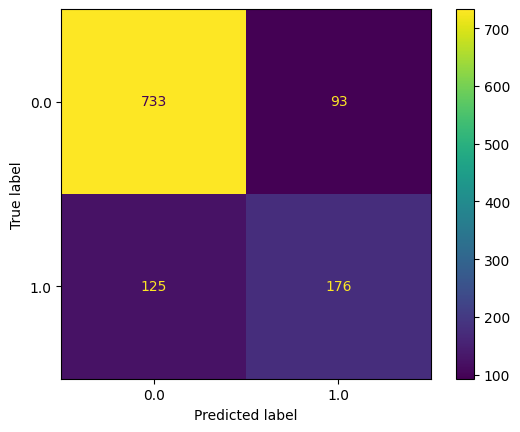

In [55]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=log_model.classes_)
plt.show()

In [56]:
#KNN

In [57]:
metric_k=[]
neighbours = np.arange(3,20)

for i in neighbours:
    knn_model = KNeighborsClassifier(n_neighbors=i)
    knn_model.fit(x_train,y_train)
    y_pred_knn = knn_model.predict(x_test)
    metric_k.append(accuracy_score(y_test,y_pred_knn))

    metric_k

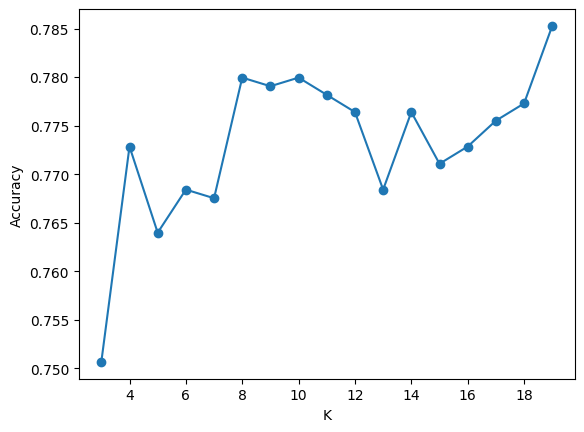

In [58]:
plt.plot(neighbours,metric_k,marker='o')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.show()

In [59]:
knn_classifier = KNeighborsClassifier(n_neighbors=11)
knn_classifier.fit(x_train,y_train)
y_pred_knn = knn_classifier.predict(x_test)
print(accuracy_score(y_test,y_pred_knn))
print(confusion_matrix(y_test,y_pred_knn))

0.7781721384205856
[[708 118]
 [132 169]]


In [60]:
#Random Forest

In [61]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(x_train,y_train)
y_pred_rf = rf_model.predict(x_test)

print(accuracy_score(y_test,y_pred_rf))
print(confusion_matrix(y_test,y_pred_rf))

0.8021295474711624
[[739  87]
 [136 165]]


In [62]:
rf_model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [63]:
rf_model = RandomForestClassifier(random_state=42,n_estimators=200,n_jobs=-1,class_weight='balanced',max_depth=10,min_samples_split=5)

rf_model.fit(x_train,y_train)
y_pred_rf = rf_model.predict(x_test)

print(accuracy_score(y_test,y_pred_rf))
print(confusion_matrix(y_test,y_pred_rf))

0.7781721384205856
[[658 168]
 [ 82 219]]


Best Model Logistic Regression - 80% Accuracy

In [64]:
#Tuning Hyper Parameters of Logistic Regression Model
log_model.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

{'solver': 'liblinear', 'penalty': 'l2', 'max_iter': 100, 'C': 10}
0.7954322740684778
0.805678793256433
              precision    recall  f1-score   support

         0.0       0.85      0.89      0.87       826
         1.0       0.65      0.58      0.62       301

    accuracy                           0.81      1127
   macro avg       0.75      0.74      0.74      1127
weighted avg       0.80      0.81      0.80      1127



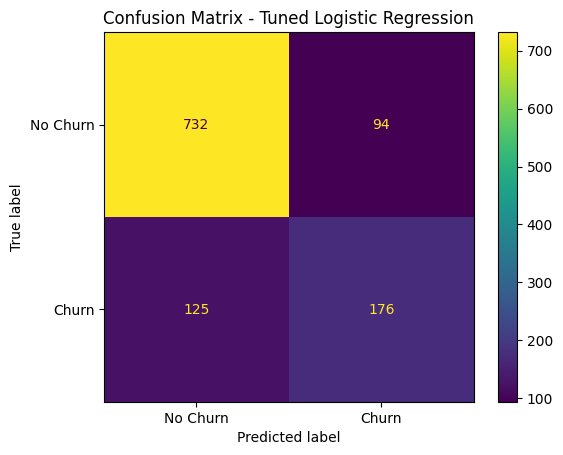

In [65]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [100, 200, 500]
}

log_random_search = RandomizedSearchCV(
    estimator=log_model,
    param_distributions=param_distributions,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

log_random_search.fit(x_train, y_train)

print(log_random_search.best_params_)
print(log_random_search.best_score_)

best_log_model = log_random_search.best_estimator_
y_pred_log_tuned = best_log_model.predict(x_test)

print(accuracy_score(y_test, y_pred_log_tuned))
print(classification_report(y_test, y_pred_log_tuned))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log_tuned, display_labels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Tuned Logistic Regression')
plt.show()


Testing


In [66]:
test_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6080-TCMYC,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.3,No
1,7285-KLOTR,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,7486-KSRVI,Male,0,No,No,43,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,9924-JPRMC,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,4439-YRNVD,Female,0,No,No,10,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374,No


In [67]:
test_df.shape

(1409, 21)

In [68]:
test_df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [81]:
test_df['gender'] = test_df['gender'].map({'Male': 0, 'Female': 1}).fillna(0.0).astype(float)
test_df['Partner'] = test_df['Partner'].map({'No': 0, 'Yes': 1}).fillna(0.0).astype(float)
test_df['Dependents'] = test_df['Dependents'].map({'No': 0, 'Yes': 1}).fillna(0.0).astype(float)
test_df['PhoneService'] = test_df['PhoneService'].map({'No': 0, 'Yes': 1}).fillna(0.0).astype(float)

test_df['MultipleLines'] = test_df['MultipleLines'].map({'No': 0.0, 'No phone service': 1.0, 'Yes': 2.0}).fillna(0.0).astype(float)
test_df['OnlineSecurity'] = test_df['OnlineSecurity'].map({'No': 0.0, 'No internet service': 1.0, 'Yes': 2.0}).fillna(0.0).astype(float)
test_df['OnlineBackup'] = test_df['OnlineBackup'].map({'No': 0.0, 'No internet service': 1.0, 'Yes': 2.0}).fillna(0.0).astype(float)
test_df['DeviceProtection'] = test_df['DeviceProtection'].map({'No': 0.0, 'No internet service': 1.0, 'Yes': 2.0}).fillna(0.0).astype(float)
test_df['TechSupport'] = test_df['TechSupport'].map({'No': 0.0, 'No internet service': 1.0, 'Yes': 2.0}).fillna(0.0).astype(float)
test_df['StreamingTV'] = test_df['StreamingTV'].map({'No': 0.0, 'No internet service': 1.0, 'Yes': 2.0}).fillna(0.0).astype(float)
test_df['StreamingMovies'] = test_df['StreamingMovies'].map({'No': 0.0, 'No internet service': 1.0, 'Yes': 2.0}).fillna(0.0).astype(float)
test_df['PaperlessBilling'] = test_df['PaperlessBilling'].map({'No': 0.0, 'Yes': 1.0}).fillna(0.0).astype(float)
test_df['Contract'] = test_df['Contract'].map({'Month-to-month': 0.0, 'One year': 1.0, 'Two year': 2.0}).fillna(0.0).astype(float)
test_df['PaymentMethod'] = test_df['PaymentMethod'].map({'Bank transfer (automatic)': 0.0, 'Credit card (automatic)': 1.0, 'Electronic check': 2.0, 'Mailed check': 3.0}).fillna(0.0).astype(float)
test_df['InternetService'] = test_df['InternetService'].map({'DSL': 0.0, 'Fiber optic': 1.0, 'No': 2.0}).fillna(0.0).astype(float)
test_df['Churn'] = test_df['Churn'].map({'No': 0.0, 'Yes': 1.0}).fillna(0.0).astype(float)

In [73]:
test_df['TotalCharges'] = pd.to_numeric(test_df['TotalCharges'], errors='coerce')
total_median_test = test_df['TotalCharges'].median()
test_df['TotalCharges'] = test_df['TotalCharges'].fillna(total_median_test)

Q1_test = np.percentile(test_df['TotalCharges'], 25, interpolation='midpoint')
Q3_test = np.percentile(test_df['TotalCharges'], 75, interpolation='midpoint')
IQR_test = Q3_test - Q1_test
lower_bound_test = Q1_test - 1.5 * IQR_test
upper_bound_test = Q3_test + 1.5 * IQR_test

for x in test_df['TotalCharges']:
  if (x < lower_bound_test) or (x > upper_bound_test):
    print(x)

In [76]:
test_df.drop('customerID', axis=1, inplace=True)

In [77]:
test_df['Customer_Lifetime_Value'] = test_df['tenure'] * test_df['MonthlyCharges']

In [83]:
y_test_final = test_df['Churn']
x_test_final = test_df.drop(columns=['Churn'])

x_test_final[num_cols] = scaler.transform(x_test_final[num_cols])

y_pred_log_tuned = log_random_search.best_estimator_.predict(x_test_final)

print("Tuned Logistic Regression Accuracy on Test Data:", accuracy_score(y_test_final, y_pred_log_tuned))

Tuned Logistic Regression Accuracy on Test Data: 0.5755855216465579
